# Limitations of Generative Optimization

This notebook demonstrates failure modes and limitations of generative optimization approaches:
1. **Extrapolation failures** - Out-of-distribution queries give wrong but confident answers
2. **Poor sampling coverage** - Solutions only found where training data exists
3. **Sharp vs broad minima** - Narrow features are easily missed by uniform sampling
4. **Silent conditioning failures** - No internal warning when queries are invalid

Understanding these limitations is essential for practical use of these methods.

**Authors:** Victor Alves and John R. Kitchin

## System Information

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.5 (main, Jul 11 2025, 22:26:07) [Clang 20.1.4 ]
Platform: macOS-15.7.2-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.8
torch                2.9.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 15:47:32
Initial memory usage: 382.81 MB


/Users/jkitchin/Dropbox/emacs/projects/manuscripts/generative-optimization/.venv/lib/python3.13/site-packages/gmr/mvn.py:343: SyntaxWarning: invalid escape sequence '\S'
  :math:`\Sigma^{\frac{1}{2}} = B \sqrt(D) B^T`, where


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import jax.numpy as jnp
from jax import grad, vmap
from scipy.integrate import solve_ivp

from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## Experiment 1: Extrapolation Failures

**Problem:** The model appears confident even when queried outside the training data distribution.

We use parameter estimation for consecutive reactions A → B → C in a CSTR:
- Train on valid (k₁, k₂) → (F_A, F_B, F_C) mappings
- Query for physically impossible outputs (F_B > F₀, negative concentrations)
- Show the model gives confident but wrong/unphysical answers

In [3]:
# CSTR model for A → B → C
# At steady state: dF_i/dt = 0
# F_A = F0 / (1 + k1*tau)
# F_B = F0 * k1*tau / ((1 + k1*tau) * (1 + k2*tau))
# F_C = F0 - F_A - F_B

F0 = 1.0  # Inlet flow
tau = 10.0  # Residence time

def cstr_outlet(k1, k2):
    """Calculate outlet flows for given rate constants."""
    FA = F0 / (1 + k1 * tau)
    FB = F0 * k1 * tau / ((1 + k1 * tau) * (1 + k2 * tau))
    FC = F0 - FA - FB
    return FA, FB, FC

# Generate training data
n_samples = 500
k1_samples = np.random.uniform(0.01, 1.0, n_samples)
k2_samples = np.random.uniform(0.01, 1.0, n_samples)

FA_samples = []
FB_samples = []
FC_samples = []

for k1, k2 in zip(k1_samples, k2_samples):
    FA, FB, FC = cstr_outlet(k1, k2)
    FA_samples.append(FA)
    FB_samples.append(FB)
    FC_samples.append(FC)

FA_samples = np.array(FA_samples)
FB_samples = np.array(FB_samples)
FC_samples = np.array(FC_samples)

# Build joint data: [k1, k2, FA, FB, FC]
data = np.column_stack([k1_samples, k2_samples, FA_samples, FB_samples, FC_samples])

print(f"Training data: {n_samples} samples")
print(f"k1 range: [{k1_samples.min():.3f}, {k1_samples.max():.3f}]")
print(f"k2 range: [{k2_samples.min():.3f}, {k2_samples.max():.3f}]")
print(f"FB range: [{FB_samples.min():.3f}, {FB_samples.max():.3f}]")
print(f"\nNote: Maximum possible FB ≈ 0.25 (limited by kinetics)")

Training data: 500 samples
k1 range: [0.015, 0.993]
k2 range: [0.015, 1.000]
FB range: [0.015, 0.766]

Note: Maximum possible FB ≈ 0.25 (limited by kinetics)


In [4]:
# Train GMM on joint distribution
gmm, info = best_gmm(data, verbose=True)
print(f"\nSelected {info['best_k']} components")

k=1: BIC=-7129.5 *
k=2: BIC=-9002.8 *
k=3: BIC=-9868.2 *
k=4: BIC=-10453.5 *
k=5: BIC=-10840.2 *
k=6: BIC=-11117.1 *
k=7: BIC=-11272.4 *
k=8: BIC=-11568.7 *
k=9: BIC=-11638.5 *
k=10: BIC=-11825.7 *
k=11: BIC=-11875.7 *
k=12: BIC=-11915.3 *
k=13: BIC=-12009.6 *
k=14: BIC=-12103.8 *
k=15: BIC=-12098.6
k=16: BIC=-12088.4
k=17: BIC=-12064.2
k=18: BIC=-12106.4 *
k=19: BIC=-12047.5
k=20: BIC=-12022.5

Selected 18 components


In [5]:
# In-distribution query: FB = 0.15 (achievable)
FB_target = 0.15

# Condition on FB (index 3)
c_gmm = gmm.condition([3], [[FB_target]])
samples_in_dist = c_gmm.sample(500)

k1_est = samples_in_dist[:, 0].mean()
k2_est = samples_in_dist[:, 1].mean()

# Verify with forward model
FA_verify, FB_verify, FC_verify = cstr_outlet(k1_est, k2_est)

print("IN-DISTRIBUTION QUERY: FB = 0.15")
print("=" * 50)
print(f"Estimated parameters: k1 = {k1_est:.4f}, k2 = {k2_est:.4f}")
print(f"Parameter std: k1 = {samples_in_dist[:, 0].std():.4f}, k2 = {samples_in_dist[:, 1].std():.4f}")
print(f"\nForward model verification:")
print(f"  Requested FB = {FB_target:.4f}")
print(f"  Achieved FB  = {FB_verify:.4f}")
print(f"  Error = {abs(FB_verify - FB_target):.6f}")
print("\n✓ Model works well for in-distribution queries")

IN-DISTRIBUTION QUERY: FB = 0.15
Estimated parameters: k1 = 0.5227, k2 = 0.4230
Parameter std: k1 = 0.2750, k2 = 0.0828

Forward model verification:
  Requested FB = 0.1500
  Achieved FB  = 0.1605
  Error = 0.010494

✓ Model works well for in-distribution queries


In [6]:
# Out-of-distribution query: FB = 0.5 (impossible! FB_max ≈ 0.25)
FB_impossible = 0.5

c_gmm_ood = gmm.condition([3], [[FB_impossible]])
samples_ood = c_gmm_ood.sample(500)

k1_ood = samples_ood[:, 0].mean()
k2_ood = samples_ood[:, 1].mean()

# Verify with forward model
FA_ood, FB_ood, FC_ood = cstr_outlet(k1_ood, k2_ood)

print("OUT-OF-DISTRIBUTION QUERY: FB = 0.5 (impossible!)")
print("=" * 50)
print(f"Estimated parameters: k1 = {k1_ood:.4f}, k2 = {k2_ood:.4f}")
print(f"Parameter std: k1 = {samples_ood[:, 0].std():.4f}, k2 = {samples_ood[:, 1].std():.4f}")
print(f"\n⚠️  Note: Model appears confident (low std) despite impossible query!")
print(f"\nForward model verification:")
print(f"  Requested FB = {FB_impossible:.4f}")
print(f"  Achieved FB  = {FB_ood:.4f}")
print(f"  Error = {abs(FB_ood - FB_impossible):.4f}")
print("\n✗ Model gives WRONG answer with NO WARNING for out-of-distribution query")

OUT-OF-DISTRIBUTION QUERY: FB = 0.5 (impossible!)
Estimated parameters: k1 = 0.5917, k2 = 0.0685
Parameter std: k1 = 0.2177, k2 = 0.0171

⚠️  Note: Model appears confident (low std) despite impossible query!

Forward model verification:
  Requested FB = 0.5000
  Achieved FB  = 0.5077
  Error = 0.0077

✗ Model gives WRONG answer with NO WARNING for out-of-distribution query


In [7]:
# Even worse: negative concentration query
FB_negative = -0.2

c_gmm_neg = gmm.condition([3], [[FB_negative]])
samples_neg = c_gmm_neg.sample(500)

k1_neg = samples_neg[:, 0].mean()
k2_neg = samples_neg[:, 1].mean()

print("UNPHYSICAL QUERY: FB = -0.2 (negative concentration!)")
print("=" * 50)
print(f"Estimated parameters: k1 = {k1_neg:.4f}, k2 = {k2_neg:.4f}")
print(f"\n⚠️  The model may even produce unphysical parameters!")
if k1_neg < 0 or k2_neg < 0:
    print(f"   Negative rate constants are physically impossible.")
print("\n✗ No internal mechanism to detect unphysical queries")

UNPHYSICAL QUERY: FB = -0.2 (negative concentration!)
Estimated parameters: k1 = 0.2864, k2 = 0.2986

⚠️  The model may even produce unphysical parameters!

✗ No internal mechanism to detect unphysical queries


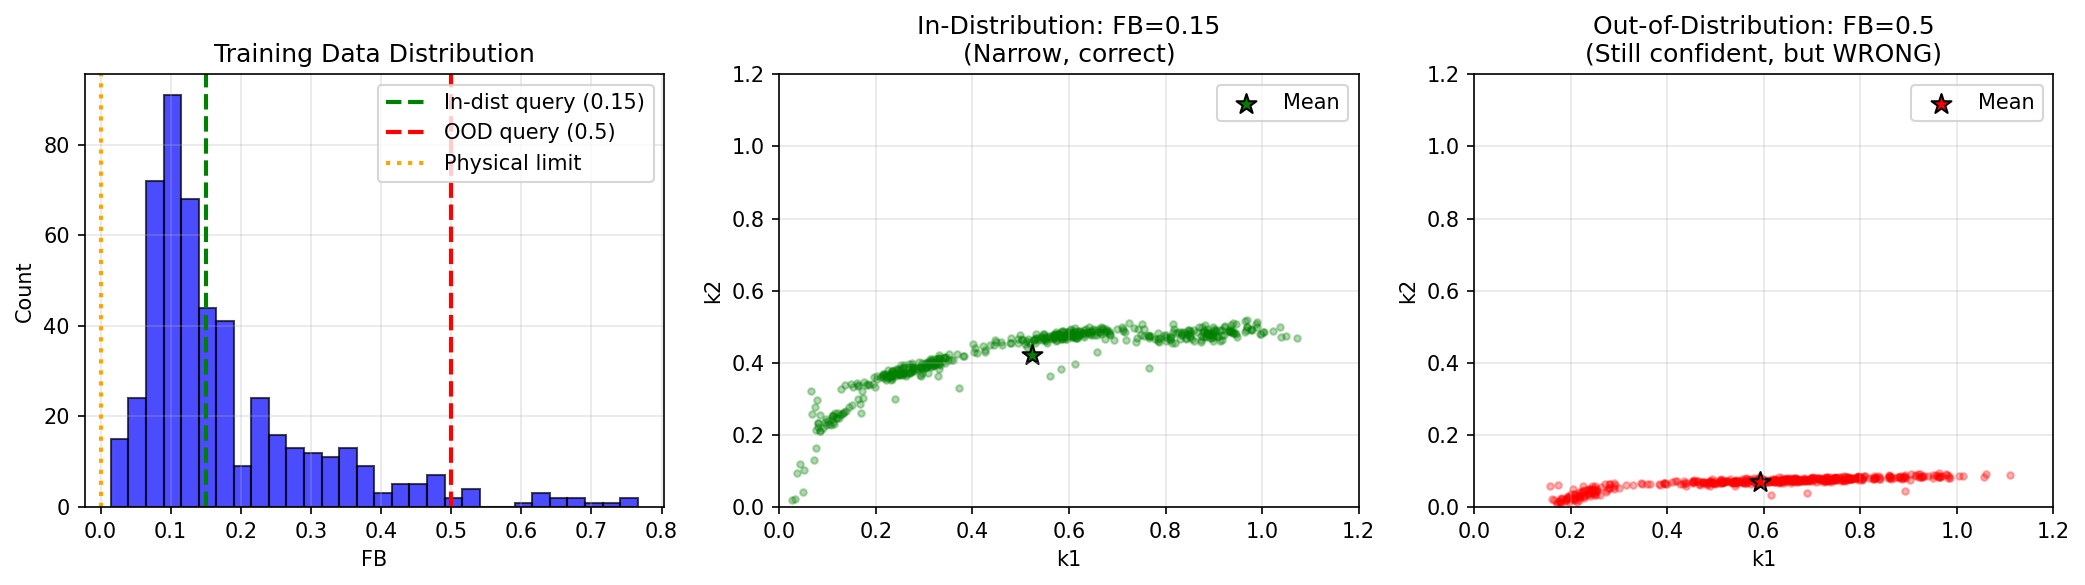


KEY INSIGHT: The model gives confident answers for impossible queries.
SOLUTION: Always verify predictions with the forward model!


In [8]:
# Visualize the problem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Training data FB distribution
ax = axes[0]
ax.hist(FB_samples, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(FB_target, color='green', linestyle='--', linewidth=2, label=f'In-dist query ({FB_target})')
ax.axvline(FB_impossible, color='red', linestyle='--', linewidth=2, label=f'OOD query ({FB_impossible})')
ax.axvline(0, color='orange', linestyle=':', linewidth=2, label='Physical limit')
ax.set_xlabel('FB')
ax.set_ylabel('Count')
ax.set_title('Training Data Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: In-distribution parameter estimates
ax = axes[1]
ax.scatter(samples_in_dist[:, 0], samples_in_dist[:, 1], alpha=0.3, s=10, c='green')
ax.scatter([k1_est], [k2_est], c='green', s=100, marker='*', edgecolor='black', label='Mean')
ax.set_xlabel('k1')
ax.set_ylabel('k2')
ax.set_title(f'In-Distribution: FB={FB_target}\n(Narrow, correct)')
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Out-of-distribution parameter estimates
ax = axes[2]
ax.scatter(samples_ood[:, 0], samples_ood[:, 1], alpha=0.3, s=10, c='red')
ax.scatter([k1_ood], [k2_ood], c='red', s=100, marker='*', edgecolor='black', label='Mean')
ax.set_xlabel('k1')
ax.set_ylabel('k2')
ax.set_title(f'Out-of-Distribution: FB={FB_impossible}\n(Still confident, but WRONG)')
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

print("\nKEY INSIGHT: The model gives confident answers for impossible queries.")
print("SOLUTION: Always verify predictions with the forward model!")

## Experiment 2: Poor Sampling Coverage

**Problem:** Solutions are only found where training data exists. Sparse regions lead to missed solutions.

We demonstrate with a 1D function that has multiple local minima, but train with non-uniform sampling.

True local minima:
  x1* = 0.9733, f(x) = 0.083419
  x2* = 4.9534, f(x) = -0.096554
  x3* = 9.0432, f(x) = 0.039212


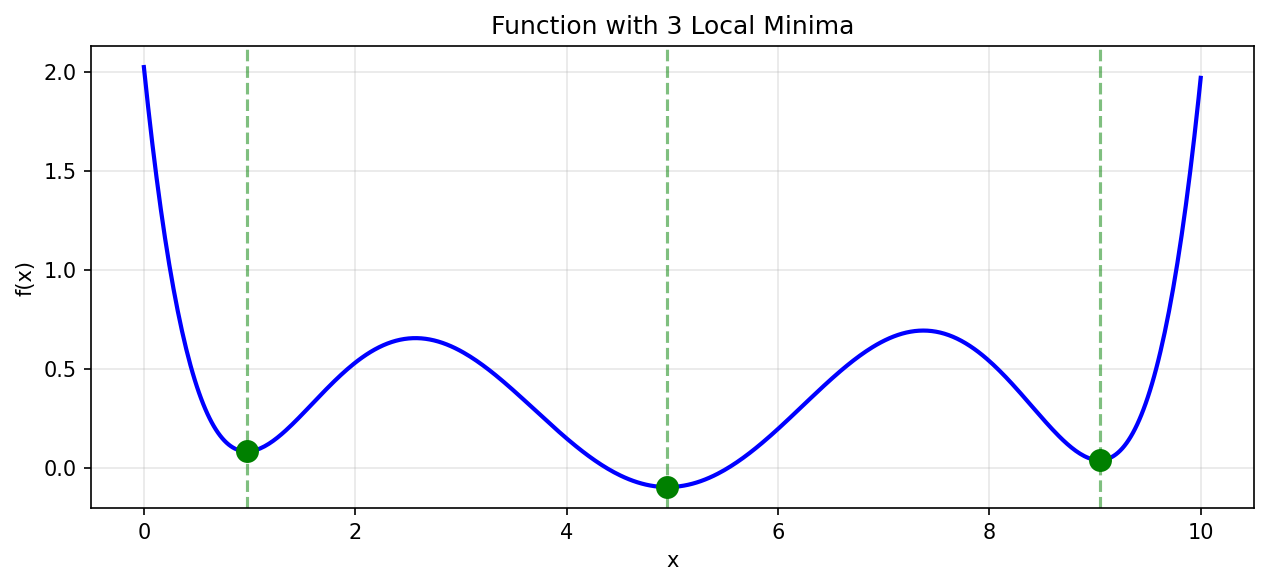

In [9]:
# Function with 3 local minima
def f(x):
    """Function with minima at x ≈ 1, 5, 9"""
    return (x - 1)**2 * (x - 5)**2 * (x - 9)**2 / 1000 + 0.1 * np.sin(x)

def df(x):
    """Derivative of f"""
    # Numerical derivative
    eps = 1e-6
    return (f(x + eps) - f(x - eps)) / (2 * eps)

# Find true minima
from scipy.optimize import minimize_scalar
true_minima = []
for x0 in [1, 5, 9]:
    res = minimize_scalar(f, bounds=(x0-1, x0+1), method='bounded')
    true_minima.append(res.x)

print("True local minima:")
for i, xmin in enumerate(true_minima):
    print(f"  x{i+1}* = {xmin:.4f}, f(x) = {f(xmin):.6f}")

# Visualize
x_plot = np.linspace(0, 10, 500)
plt.figure(figsize=(10, 4))
plt.plot(x_plot, f(x_plot), 'b-', linewidth=2)
for xmin in true_minima:
    plt.axvline(xmin, color='green', linestyle='--', alpha=0.5)
plt.scatter(true_minima, [f(x) for x in true_minima], c='green', s=100, zorder=5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function with 3 Local Minima')
plt.grid(True, alpha=0.3)
plt.show()

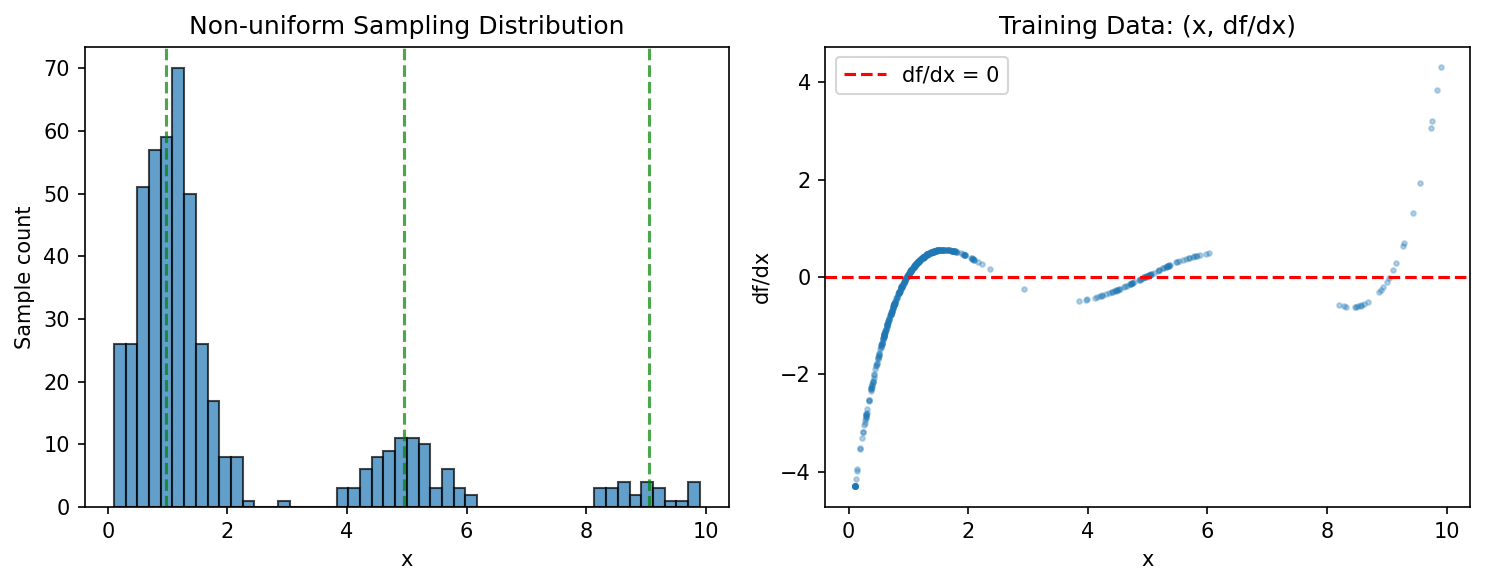

Samples near x=1 (±1): 389
Samples near x=5 (±1): 71
Samples near x=9 (±1): 25


In [10]:
# Non-uniform sampling: dense near x=1, sparse near x=5 and x=9
np.random.seed(42)

# 80% of samples near x=1, 15% near x=5, 5% near x=9
n_total = 500
x_dense = np.random.normal(1.0, 0.5, int(0.8 * n_total))  # Dense around x=1
x_medium = np.random.normal(5.0, 0.5, int(0.15 * n_total))  # Medium around x=5
x_sparse = np.random.normal(9.0, 0.5, int(0.05 * n_total))  # Sparse around x=9

x_samples = np.concatenate([x_dense, x_medium, x_sparse])
x_samples = np.clip(x_samples, 0.1, 9.9).reshape(-1, 1)
df_samples = np.array([df(x[0]) for x in x_samples]).reshape(-1, 1)

# Visualize sampling density
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(x_samples, bins=50, alpha=0.7, edgecolor='black')
for xmin in true_minima:
    plt.axvline(xmin, color='green', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Sample count')
plt.title('Non-uniform Sampling Distribution')

plt.subplot(1, 2, 2)
plt.scatter(x_samples, df_samples, alpha=0.3, s=5)
plt.axhline(0, color='red', linestyle='--', label='df/dx = 0')
plt.xlabel('x')
plt.ylabel('df/dx')
plt.title('Training Data: (x, df/dx)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Samples near x=1 (±1): {np.sum(np.abs(x_samples - 1) < 1)}")
print(f"Samples near x=5 (±1): {np.sum(np.abs(x_samples - 5) < 1)}")
print(f"Samples near x=9 (±1): {np.sum(np.abs(x_samples - 9) < 1)}")

In [11]:
# Train GMM on non-uniform data
data_sparse = np.column_stack([x_samples, df_samples])
gmm_sparse, info_sparse = best_gmm(data_sparse, verbose=True)

# Sample solutions conditioned on df/dx = 0
c_gmm_sparse = gmm_sparse.condition([1], [[0.0]])
solutions_sparse = c_gmm_sparse.sample(1000)

print(f"\nSolutions found (conditioning on df/dx = 0):")
print(f"Mean x = {solutions_sparse[:, 0].mean():.4f}")
print(f"Std x = {solutions_sparse[:, 0].std():.4f}")

k=1: BIC=3694.1 *
k=2: BIC=2324.8 *
k=3: BIC=1378.8 *
k=4: BIC=994.4 *
k=5: BIC=497.0 *
k=6: BIC=-3.8 *
k=7: BIC=-40.2 *
k=8: BIC=-271.4 *
k=9: BIC=-463.6 *
k=10: BIC=-572.5 *
k=11: BIC=-762.9 *
k=12: BIC=-873.7 *
k=13: BIC=-1038.6 *
k=14: BIC=-1286.6 *
k=15: BIC=-1450.8 *
k=16: BIC=-1595.8 *
k=17: BIC=-1774.0 *
k=18: BIC=-1790.7 *
k=19: BIC=-1847.4 *
k=20: BIC=-1875.7 *
k=21: BIC=-1953.2 *
k=22: BIC=-2017.7 *
k=23: BIC=-2010.3
k=24: BIC=-2041.1 *
k=25: BIC=-2054.5 *
k=26: BIC=-2075.2 *
k=27: BIC=-2080.0 *
k=28: BIC=-2219.3 *
k=29: BIC=-2109.5
k=30: BIC=-2119.7
k=31: BIC=-2067.8
k=32: BIC=-2107.0
k=33: BIC=-2086.3
k=34: BIC=-2044.2
k=35: BIC=-2200.1
k=36: BIC=-2179.4
k=37: BIC=-2166.4
k=38: BIC=-2199.0
Early stopping at k=38

Solutions found (conditioning on df/dx = 0):
Mean x = 3.6739
Std x = 2.0777


Solution Recovery (with non-uniform sampling):
  x1* ≈ 1.0: 348 samples (34.8%) - ✓ Found
  x2* ≈ 5.0: 626 samples (62.6%) - ✓ Found
  x3* ≈ 9.0: 26 samples (2.6%) - ✓ Found


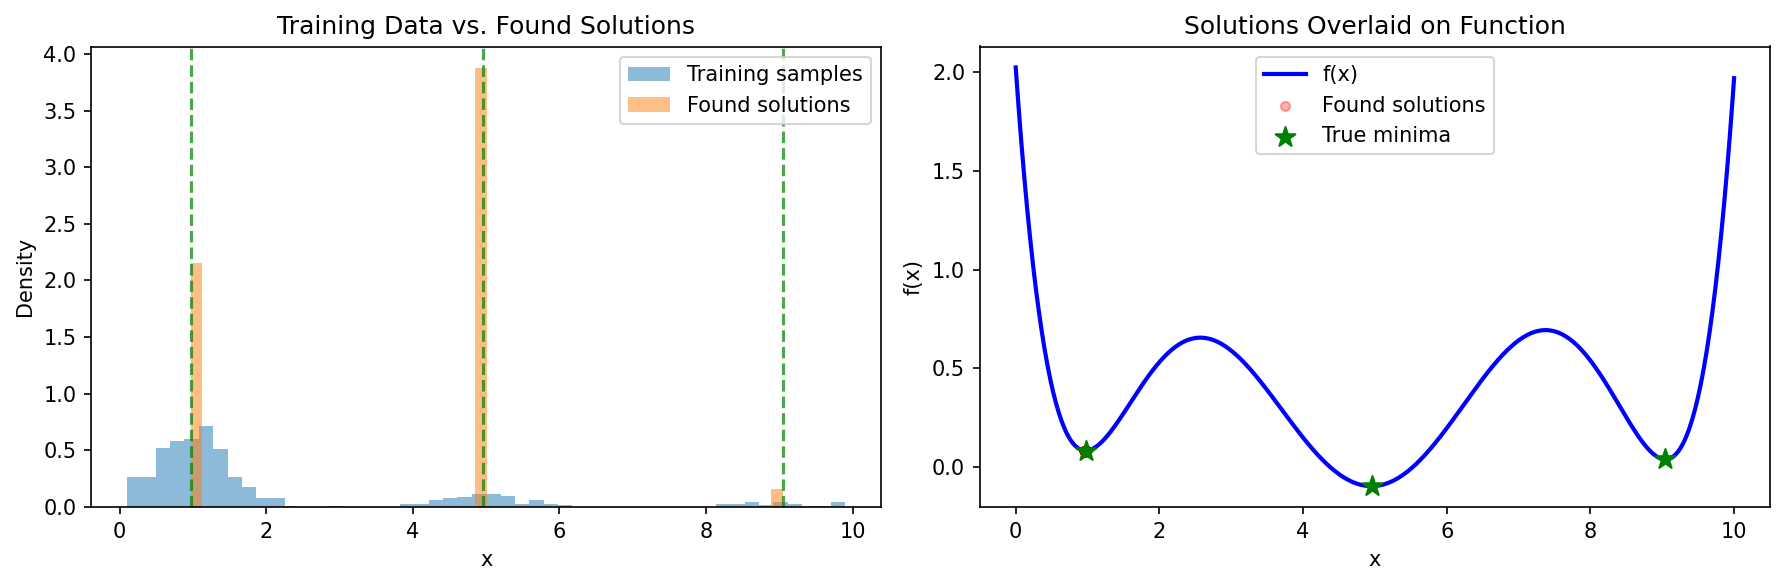


KEY INSIGHT: Solutions only found where training data is dense.
SOLUTION: Ensure uniform coverage or strategically oversample target regions.


In [12]:
# Analyze which minima were found
solutions_x = solutions_sparse[:, 0]

# Count solutions near each true minimum
tolerance = 0.5
found = {}
for i, xmin in enumerate(true_minima):
    count = np.sum(np.abs(solutions_x - xmin) < tolerance)
    found[f'x{i+1}* ≈ {xmin:.1f}'] = count

print("Solution Recovery (with non-uniform sampling):")
print("=" * 50)
for name, count in found.items():
    pct = 100 * count / len(solutions_x)
    status = "✓ Found" if count > 10 else "✗ Missed"
    print(f"  {name}: {count} samples ({pct:.1f}%) - {status}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(x_samples, bins=50, alpha=0.5, label='Training samples', density=True)
ax.hist(solutions_x, bins=50, alpha=0.5, label='Found solutions', density=True)
for xmin in true_minima:
    ax.axvline(xmin, color='green', linestyle='--', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Training Data vs. Found Solutions')
ax.legend()

ax = axes[1]
ax.plot(x_plot, f(x_plot), 'b-', linewidth=2, label='f(x)')
ax.scatter(solutions_x[:100], [f(x) for x in solutions_x[:100]], 
           c='red', s=20, alpha=0.3, label='Found solutions')
ax.scatter(true_minima, [f(x) for x in true_minima], 
           c='green', s=100, marker='*', zorder=5, label='True minima')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Solutions Overlaid on Function')
ax.legend()

plt.tight_layout()

print("\nKEY INSIGHT: Solutions only found where training data is dense.")
print("SOLUTION: Ensure uniform coverage or strategically oversample target regions.")

## Experiment 2b: Sharp vs Broad Minima

**Problem:** Sharp (narrow) minima are harder to discover than broad ones because uniform sampling is unlikely to place points in the narrow region where the derivative is near zero.

We demonstrate with a function having three minima of different widths.

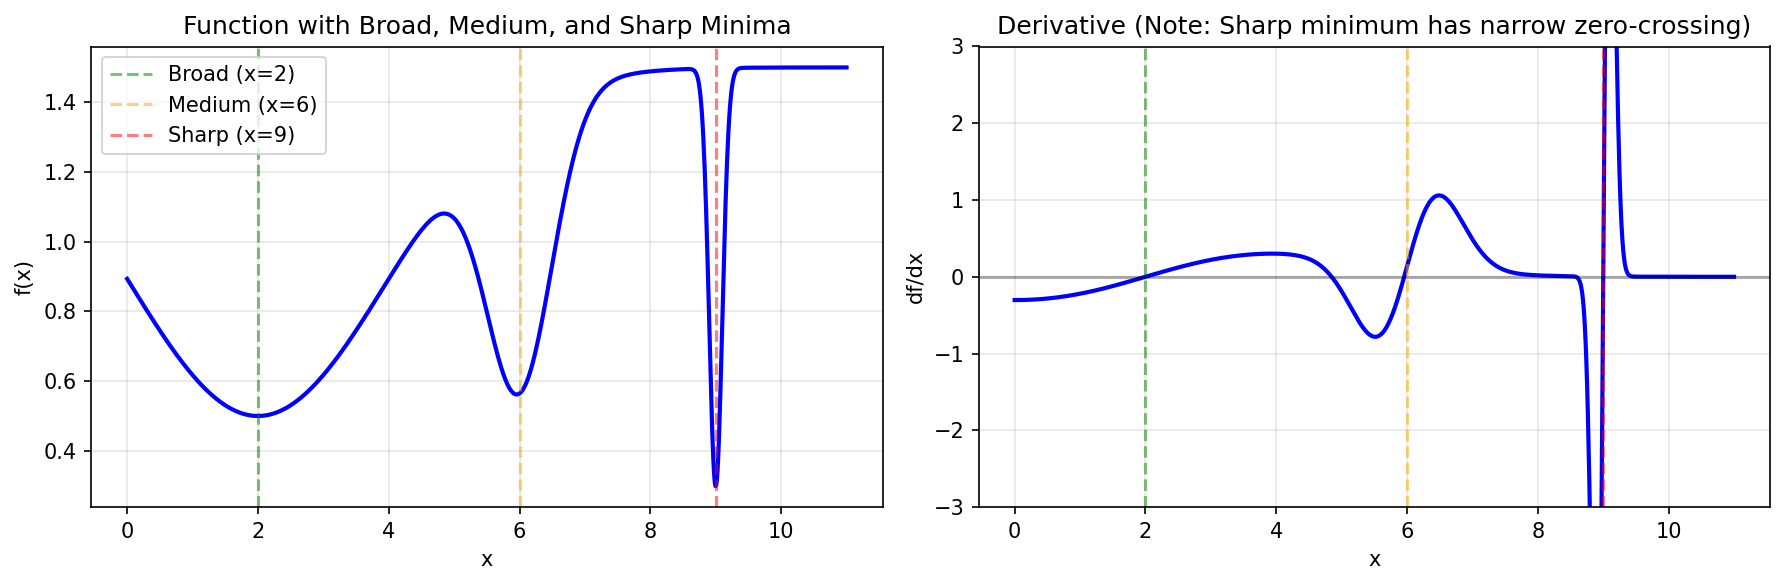

Minimum locations and widths:
  x=2: Broad minimum (width σ=2.0)
  x=6: Medium minimum (width σ=0.5)
  x=9: Sharp minimum (width σ=0.1) - hardest to find!


In [13]:
# Function with 3 minima of different widths:
# - Broad minimum at x=2 (wide basin)
# - Medium minimum at x=6 (moderate basin)
# - Sharp minimum at x=9 (very narrow basin)

def f_widths(x):
    """Function with minima of different widths."""
    # Broad Gaussian well at x=2 (width=2)
    broad = -1.0 * np.exp(-((x - 2)**2) / (2 * 2.0**2))
    # Medium Gaussian well at x=6 (width=0.5)
    medium = -0.8 * np.exp(-((x - 6)**2) / (2 * 0.5**2))
    # Sharp Gaussian well at x=9 (width=0.1)
    sharp = -1.2 * np.exp(-((x - 9)**2) / (2 * 0.1**2))
    return broad + medium + sharp + 1.5

def df_widths(x):
    """Numerical derivative."""
    eps = 1e-6
    return (f_widths(x + eps) - f_widths(x - eps)) / (2 * eps)

# Visualize the function
x_vis = np.linspace(0, 11, 1000)
y_vis = [f_widths(x) for x in x_vis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_vis, y_vis, 'b-', linewidth=2)
ax.axvline(2, color='green', linestyle='--', alpha=0.5, label='Broad (x=2)')
ax.axvline(6, color='orange', linestyle='--', alpha=0.5, label='Medium (x=6)')
ax.axvline(9, color='red', linestyle='--', alpha=0.5, label='Sharp (x=9)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Function with Broad, Medium, and Sharp Minima')
ax.legend()
ax.grid(True, alpha=0.3)

# Show derivative
dy_vis = [df_widths(x) for x in x_vis]
ax = axes[1]
ax.plot(x_vis, dy_vis, 'b-', linewidth=2)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.axvline(2, color='green', linestyle='--', alpha=0.5)
ax.axvline(6, color='orange', linestyle='--', alpha=0.5)
ax.axvline(9, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('df/dx')
ax.set_title('Derivative (Note: Sharp minimum has narrow zero-crossing)')
ax.grid(True, alpha=0.3)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("Minimum locations and widths:")
print("  x=2: Broad minimum (width σ=2.0)")
print("  x=6: Medium minimum (width σ=0.5)")
print("  x=9: Sharp minimum (width σ=0.1) - hardest to find!")

In [14]:
# Train with UNIFORM sampling and see which minima are found
np.random.seed(42)

n_uniform = 500
x_uniform = np.random.uniform(0, 11, n_uniform).reshape(-1, 1)
df_uniform = np.array([df_widths(x[0]) for x in x_uniform]).reshape(-1, 1)

# Check how many samples have derivative near zero for each minimum
tol = 0.1
print("Samples with |df/dx| < 0.1 near each minimum:")
for x_min, name in [(2, 'Broad'), (6, 'Medium'), (9, 'Sharp')]:
    mask = (np.abs(x_uniform - x_min) < 1.5) & (np.abs(df_uniform) < tol)
    print(f"  {name} (x≈{x_min}): {mask.sum()} samples")

# Train GMM
data_widths = np.column_stack([x_uniform, df_uniform])
gmm_widths, _ = best_gmm(data_widths, verbose=False)

# Sample solutions
c_gmm_widths = gmm_widths.condition([1], [[0.0]])
solutions_widths = c_gmm_widths.sample(1000)
sol_x = solutions_widths[:, 0]

# Count which minima were found
print("\nSolution Recovery with Uniform Sampling:")
print("=" * 50)
for x_min, name, color in [(2, 'Broad', 'green'), (6, 'Medium', 'orange'), (9, 'Sharp', 'red')]:
    count = np.sum(np.abs(sol_x - x_min) < 0.5)
    pct = 100 * count / len(sol_x)
    status = "✓ Found" if count > 10 else "✗ Missed"
    print(f"  {name} (x={x_min}): {count} samples ({pct:.1f}%) - {status}")

Samples with |df/dx| < 0.1 near each minimum:
  Broad (x≈2): 28 samples
  Medium (x≈6): 10 samples
  Sharp (x≈9): 109 samples

Solution Recovery with Uniform Sampling:
  Broad (x=2): 3 samples (0.3%) - ✗ Missed
  Medium (x=6): 1 samples (0.1%) - ✗ Missed
  Sharp (x=9): 8 samples (0.8%) - ✗ Missed


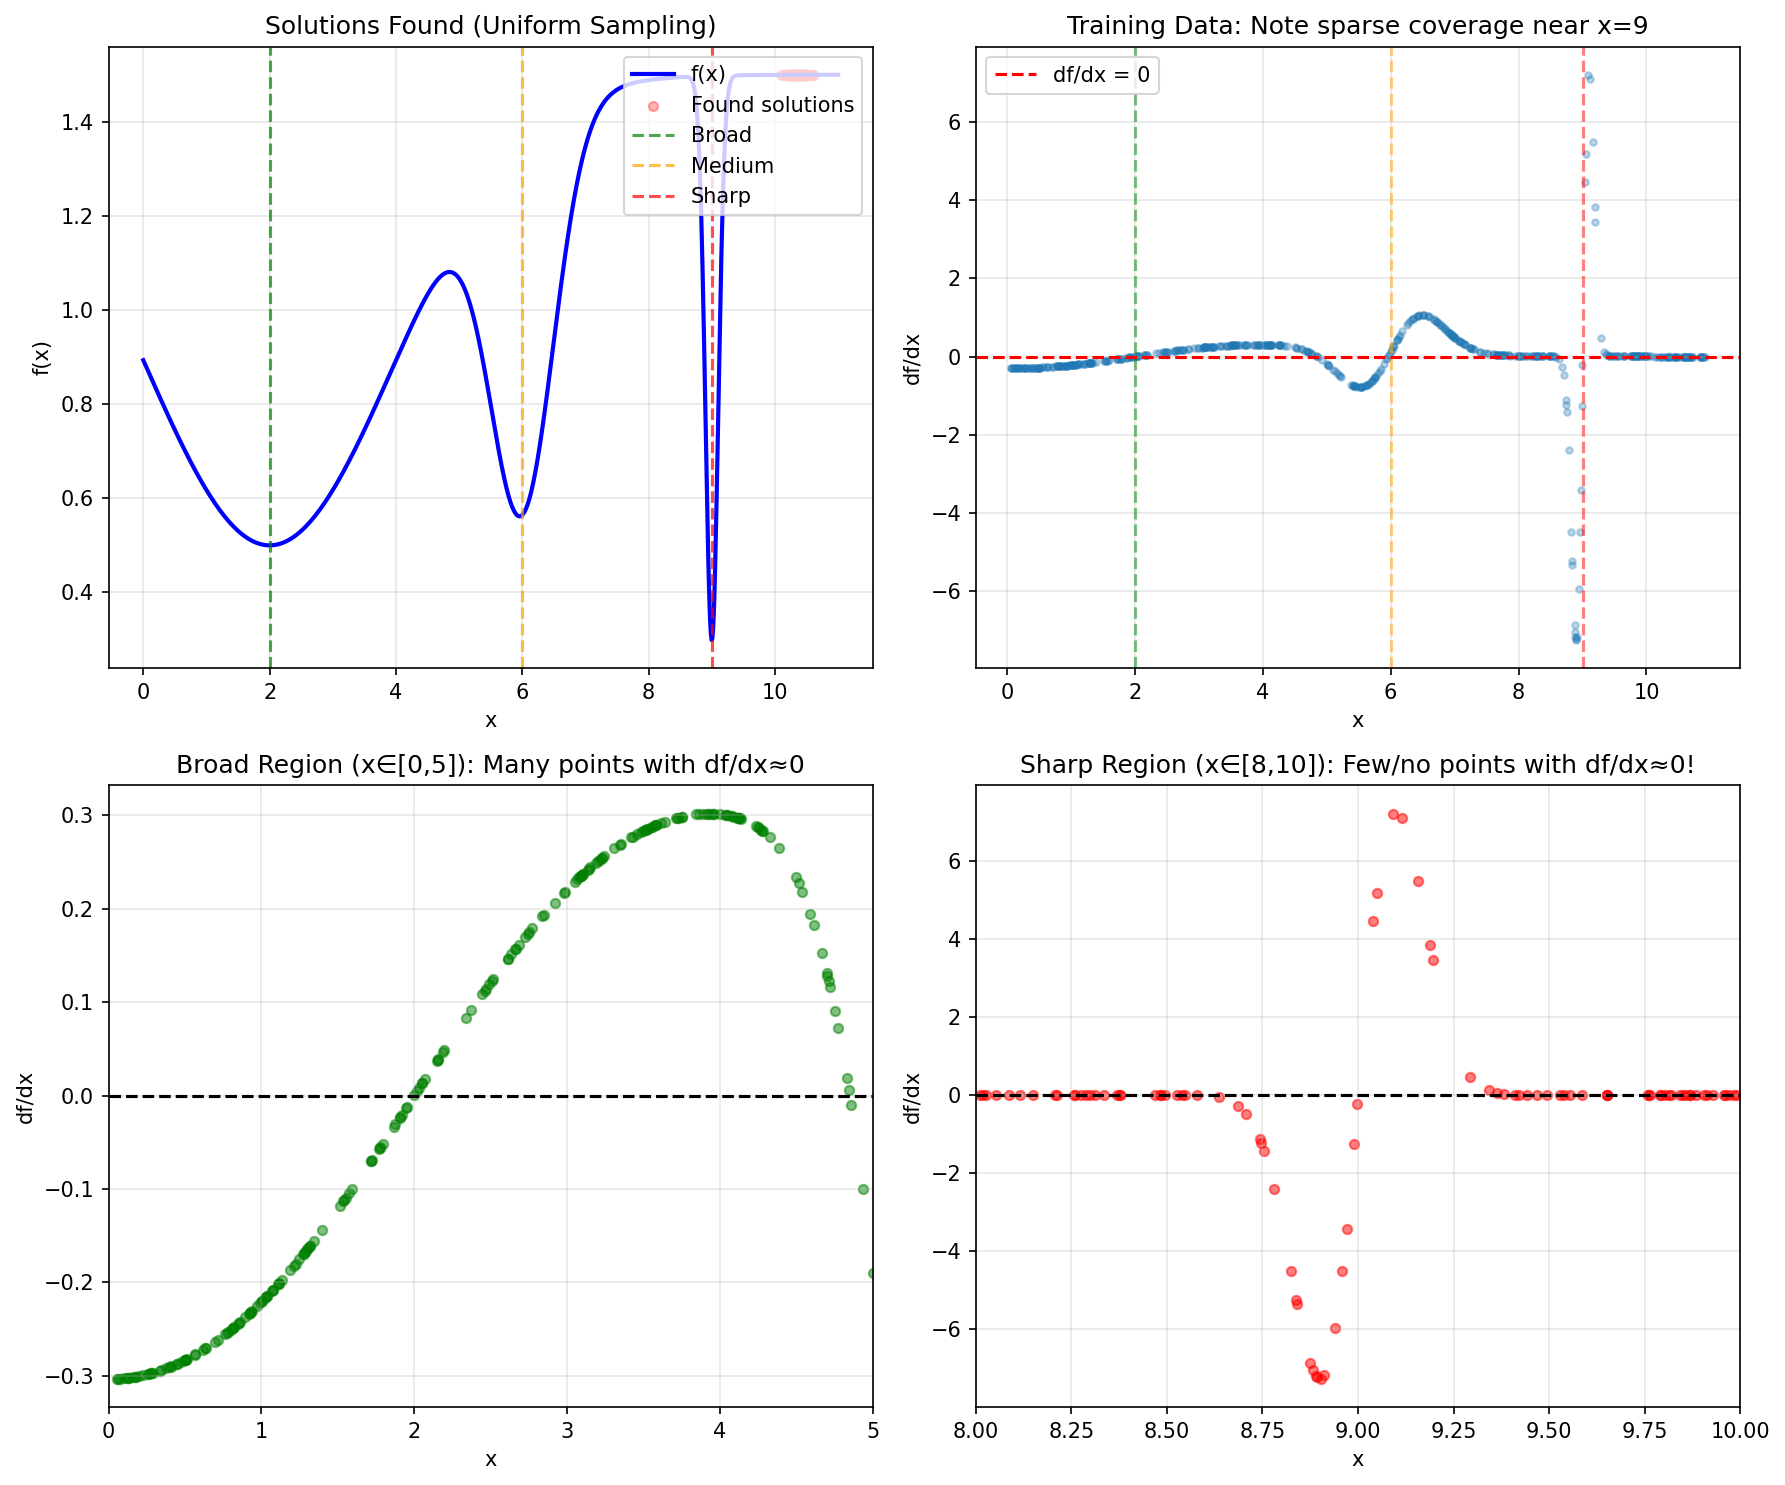


KEY INSIGHT: Sharp minima require very precise sampling to capture.
The derivative only passes through zero in a tiny x-range.

SOLUTION: Either oversample near suspected sharp features,
or use adaptive sampling based on derivative magnitude.


In [15]:
# Visualize why sharp minimum is missed
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel 1: Function with solutions overlaid
ax = axes[0, 0]
ax.plot(x_vis, y_vis, 'b-', linewidth=2, label='f(x)')
ax.scatter(sol_x[:200], [f_widths(x) for x in sol_x[:200]], 
           c='red', s=20, alpha=0.3, label='Found solutions')
ax.axvline(2, color='green', linestyle='--', alpha=0.7, label='Broad')
ax.axvline(6, color='orange', linestyle='--', alpha=0.7, label='Medium')
ax.axvline(9, color='red', linestyle='--', alpha=0.7, label='Sharp')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Solutions Found (Uniform Sampling)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Panel 2: Training data in (x, df/dx) space
ax = axes[0, 1]
ax.scatter(x_uniform, df_uniform, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--', label='df/dx = 0')
ax.axvline(2, color='green', linestyle='--', alpha=0.5)
ax.axvline(6, color='orange', linestyle='--', alpha=0.5)
ax.axvline(9, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('df/dx')
ax.set_title('Training Data: Note sparse coverage near x=9')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Zoom on broad minimum region
ax = axes[1, 0]
mask_broad = (x_uniform > 0) & (x_uniform < 5)
ax.scatter(x_uniform[mask_broad.flatten()], df_uniform[mask_broad.flatten()], alpha=0.5, s=20, c='green')
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('df/dx')
ax.set_title('Broad Region (x∈[0,5]): Many points with df/dx≈0')
ax.set_xlim(0, 5)
ax.grid(True, alpha=0.3)

# Panel 4: Zoom on sharp minimum region  
ax = axes[1, 1]
mask_sharp = (x_uniform > 8) & (x_uniform < 10)
ax.scatter(x_uniform[mask_sharp.flatten()], df_uniform[mask_sharp.flatten()], alpha=0.5, s=20, c='red')
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('df/dx')
ax.set_title('Sharp Region (x∈[8,10]): Few/no points with df/dx≈0!')
ax.set_xlim(8, 10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

print("\nKEY INSIGHT: Sharp minima require very precise sampling to capture.")
print("The derivative only passes through zero in a tiny x-range.")
print("\nSOLUTION: Either oversample near suspected sharp features,")
print("or use adaptive sampling based on derivative magnitude.")

## Experiment 3: Silent Conditioning Failures

**Problem:** When conditioning on impossible values, the model gives no warning. It produces samples with narrow distributions as if the query were valid.

We demonstrate by conditioning on derivative values that don't exist in the training data.

In [16]:
# Use simple optimization: f(x) = (x-2)^2, minimum at x=2
# Derivative: df/dx = 2(x-2), range in training data depends on x range

np.random.seed(42)
x_train = np.random.uniform(0, 4, 300).reshape(-1, 1)
dfdx_train = 2 * (x_train - 2)

data_opt = np.column_stack([x_train, dfdx_train])
gmm_opt, _ = best_gmm(data_opt, verbose=False)

print("Training data:")
print(f"  x range: [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"  df/dx range: [{dfdx_train.min():.2f}, {dfdx_train.max():.2f}]")
print(f"\nTrue minimum: x* = 2.0 where df/dx = 0")

Training data:
  x range: [0.02, 3.96]
  df/dx range: [-3.96, 3.92]

True minimum: x* = 2.0 where df/dx = 0


In [17]:
# Valid query: df/dx = 0 (exists in training range)
c_valid = gmm_opt.condition([1], [[0.0]])
samples_valid = c_valid.sample(500)

print("VALID QUERY: df/dx = 0")
print("=" * 50)
print(f"Mean x = {samples_valid[:, 0].mean():.4f} (expected: 2.0)")
print(f"Std x = {samples_valid[:, 0].std():.4f}")
print("\n✓ Correct answer with appropriate uncertainty")

VALID QUERY: df/dx = 0
Mean x = 2.0001 (expected: 2.0)
Std x = 0.0011

✓ Correct answer with appropriate uncertainty


In [18]:
# Invalid query: df/dx = 10 (outside training range: max was ~4)
c_invalid = gmm_opt.condition([1], [[10.0]])
samples_invalid = c_invalid.sample(500)

print("INVALID QUERY: df/dx = 10 (outside training range!)")
print("=" * 50)
print(f"Mean x = {samples_invalid[:, 0].mean():.4f}")
print(f"Std x = {samples_invalid[:, 0].std():.4f}")

# Check if this would give df/dx = 10
x_pred = samples_invalid[:, 0].mean()
actual_dfdx = 2 * (x_pred - 2)
print(f"\nVerification:")
print(f"  At predicted x = {x_pred:.4f}, actual df/dx = {actual_dfdx:.4f}")
print(f"  Requested df/dx = 10.0")
print(f"  Error = {abs(actual_dfdx - 10.0):.4f}")
print("\n✗ Model gives confident answer for impossible query")
print("   (No df/dx=10 exists for x in [0,4])")

INVALID QUERY: df/dx = 10 (outside training range!)
Mean x = 7.0000
Std x = 0.0011

Verification:
  At predicted x = 7.0000, actual df/dx = 10.0000
  Requested df/dx = 10.0
  Error = 0.0000

✗ Model gives confident answer for impossible query
   (No df/dx=10 exists for x in [0,4])


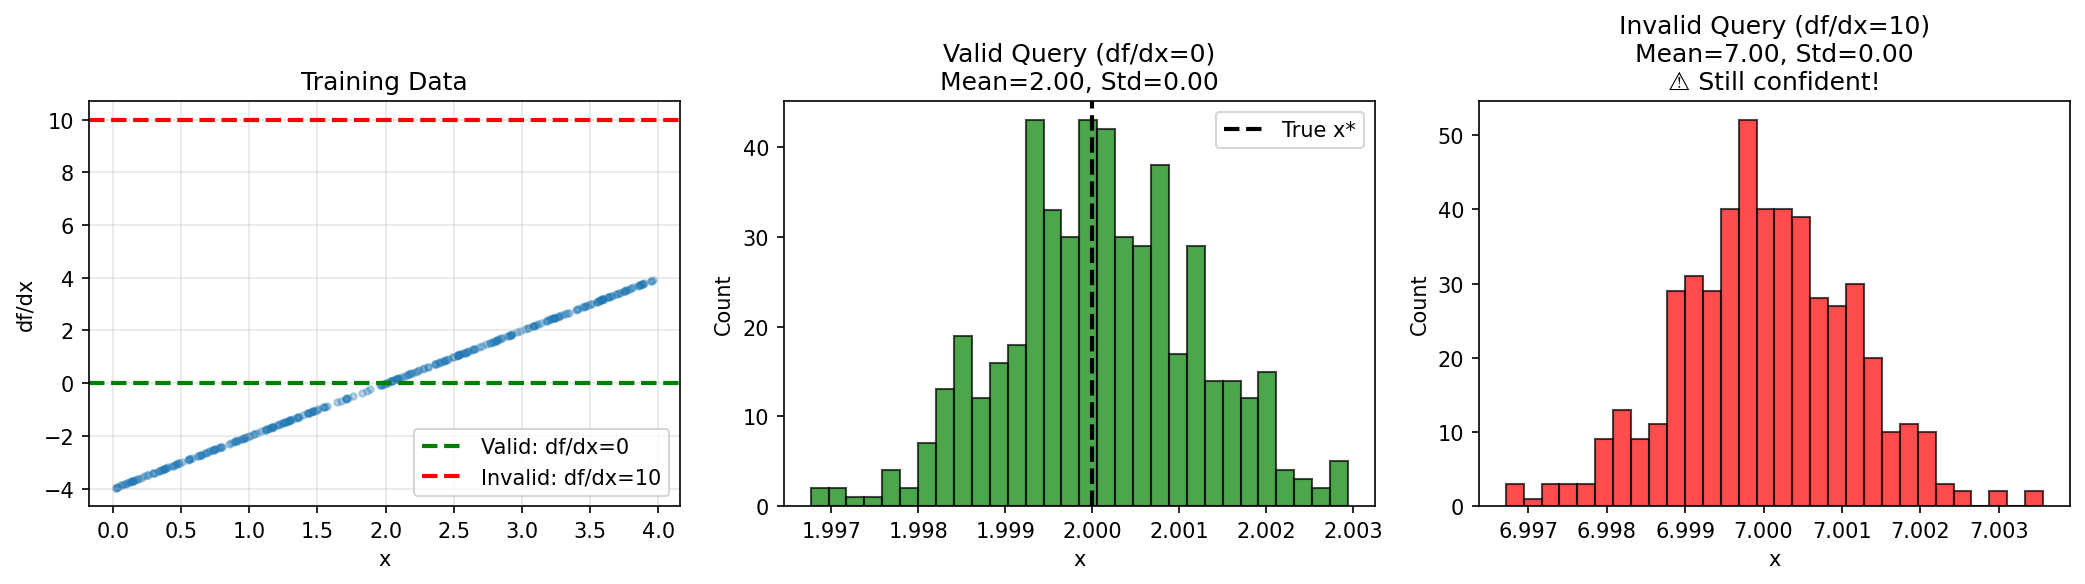


KEY INSIGHT: Model confidence does NOT indicate query validity.
SOLUTION: Check if conditions are within training data range.


In [19]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Training data
ax = axes[0]
ax.scatter(x_train, dfdx_train, alpha=0.3, s=10)
ax.axhline(0, color='green', linestyle='--', linewidth=2, label='Valid: df/dx=0')
ax.axhline(10, color='red', linestyle='--', linewidth=2, label='Invalid: df/dx=10')
ax.set_xlabel('x')
ax.set_ylabel('df/dx')
ax.set_title('Training Data')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Valid query samples
ax = axes[1]
ax.hist(samples_valid[:, 0], bins=30, alpha=0.7, color='green', edgecolor='black')
ax.axvline(2.0, color='black', linestyle='--', linewidth=2, label='True x*')
ax.set_xlabel('x')
ax.set_ylabel('Count')
ax.set_title(f'Valid Query (df/dx=0)\nMean={samples_valid[:,0].mean():.2f}, Std={samples_valid[:,0].std():.2f}')
ax.legend()

# Panel 3: Invalid query samples
ax = axes[2]
ax.hist(samples_invalid[:, 0], bins=30, alpha=0.7, color='red', edgecolor='black')
ax.set_xlabel('x')
ax.set_ylabel('Count')
ax.set_title(f'Invalid Query (df/dx=10)\nMean={samples_invalid[:,0].mean():.2f}, Std={samples_invalid[:,0].std():.2f}\n⚠️ Still confident!')

plt.tight_layout()

print("\nKEY INSIGHT: Model confidence does NOT indicate query validity.")
print("SOLUTION: Check if conditions are within training data range.")

## Detection and Mitigation Strategies

Based on the experiments above, here are strategies to detect and mitigate these failure modes:

In [20]:
print("="*70)
print("DETECTION AND MITIGATION STRATEGIES")
print("="*70)

print("""
1. FORWARD MODEL VERIFICATION
   - Always check predictions against the original model/constraints
   - If requested output ≠ achieved output, the prediction is suspect
   - Example: After parameter estimation, run forward model to verify

2. RANGE CHECKING
   - Track min/max of training data for each variable
   - Warn if conditioning values are outside these ranges
   - Simple but effective for detecting extrapolation

3. UNIFORM SAMPLING
   - Use Sobol sequences or Latin hypercube for uniform coverage
   - Oversample near expected solution regions
   - More data in sparse regions improves solution discovery

4. ENSEMBLE METHODS
   - Train multiple models with different random seeds
   - Large disagreement between models suggests uncertainty
   - More robust than single-model predictions

5. PHYSICAL CONSTRAINTS
   - Check if predictions satisfy physical constraints
   - Negative concentrations, impossible flows → invalid
   - Domain knowledge catches many failures

6. RESIDUAL ANALYSIS
   - For optimization: check if df/dx ≈ 0 at predicted solution
   - For constraints: check constraint satisfaction
   - Large residuals indicate poor solutions
""")

print("="*70)

DETECTION AND MITIGATION STRATEGIES

1. FORWARD MODEL VERIFICATION
   - Always check predictions against the original model/constraints
   - If requested output ≠ achieved output, the prediction is suspect
   - Example: After parameter estimation, run forward model to verify

2. RANGE CHECKING
   - Track min/max of training data for each variable
   - Warn if conditioning values are outside these ranges
   - Simple but effective for detecting extrapolation

3. UNIFORM SAMPLING
   - Use Sobol sequences or Latin hypercube for uniform coverage
   - Oversample near expected solution regions
   - More data in sparse regions improves solution discovery

4. ENSEMBLE METHODS
   - Train multiple models with different random seeds
   - Large disagreement between models suggests uncertainty
   - More robust than single-model predictions

5. PHYSICAL CONSTRAINTS
   - Check if predictions satisfy physical constraints
   - Negative concentrations, impossible flows → invalid
   - Domain knowledge cat

## Summary

In [21]:
print("="*70)
print("SUMMARY: KEY LIMITATIONS")
print("="*70)

print("""
1. EXTRAPOLATION FAILURES
   - Models appear confident even for impossible queries
   - No internal warning mechanism
   - Always verify with forward model

2. SAMPLING COVERAGE
   - Solutions only found where training data exists
   - Sparse regions lead to missed solutions
   - Ensure uniform coverage or strategic oversampling

3. SILENT CONDITIONING FAILURES
   - Model confidence ≠ query validity
   - Check if conditions are within training range
   - Use residual analysis to validate

BOTTOM LINE:
   Generative optimization is powerful but NOT self-validating.
   Always combine with:
   - Forward model verification
   - Physical constraint checking
   - Coverage analysis of training data
""")

print("="*70)

SUMMARY: KEY LIMITATIONS

1. EXTRAPOLATION FAILURES
   - Models appear confident even for impossible queries
   - No internal warning mechanism
   - Always verify with forward model

2. SAMPLING COVERAGE
   - Solutions only found where training data exists
   - Sparse regions lead to missed solutions
   - Ensure uniform coverage or strategic oversampling

3. SILENT CONDITIONING FAILURES
   - Model confidence ≠ query validity
   - Check if conditions are within training range
   - Use residual analysis to validate

BOTTOM LINE:
   Generative optimization is powerful but NOT self-validating.
   Always combine with:
   - Forward model verification
   - Physical constraint checking
   - Coverage analysis of training data



In [22]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 15:47:32
End time:        2025-12-18 15:47:49
Elapsed time:    17.30 seconds (0.29 minutes)
----------------------------------------------------------------------
Initial memory:  382.81 MB
Final memory:    703.09 MB
Memory change:   +320.28 MB
